In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/brain.zip.zip'   # your uploaded zip
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [3]:
import os

os.listdir('/content')


['.config', 'drive', 'dataset', 'sample_data']

In [4]:
os.listdir('/content/dataset')


['kaggle_3m']

In [5]:
os.listdir('/content/dataset/kaggle_3m')


['TCGA_FG_8189_20030516',
 'TCGA_DU_8163_19961119',
 'TCGA_DU_8165_19970205',
 'TCGA_FG_A4MU_20030903',
 'TCGA_HT_8114_19981030',
 'TCGA_DU_7301_19911112',
 'TCGA_DU_6408_19860521',
 'TCGA_HT_7860_19960513',
 'TCGA_DU_A5TT_19980318',
 'TCGA_DU_7300_19910814',
 'TCGA_HT_7608_19940304',
 'TCGA_CS_6667_20011105',
 'TCGA_DU_6399_19830416',
 'TCGA_DU_7304_19930325',
 'TCGA_HT_7879_19981009',
 'TCGA_CS_4944_20010208',
 'TCGA_HT_7690_19960312',
 'TCGA_DU_7010_19860307',
 'TCGA_FG_6689_20020326',
 'TCGA_HT_A61A_20000127',
 'TCGA_HT_8113_19930809',
 'TCGA_CS_4943_20000902',
 'TCGA_DU_7299_19910417',
 'TCGA_CS_5396_20010302',
 'TCGA_DU_7014_19860618',
 'TCGA_HT_7605_19950916',
 'TCGA_HT_7684_19950816',
 'TCGA_HT_7884_19980913',
 'TCGA_HT_8105_19980826',
 'TCGA_CS_6188_20010812',
 'TCGA_DU_7306_19930512',
 'TCGA_HT_8107_19980708',
 'TCGA_FG_6690_20020226',
 'TCGA_EZ_7264_20010816',
 'TCGA_HT_7882_19970125',
 'TCGA_HT_7686_19950629',
 'TCGA_HT_7602_19951103',
 'TCGA_DU_A5TW_19980228',
 'TCGA_FG_76

In [6]:
import os

root_dir = '/content/dataset/kaggle_3m'

# Pick ONE patient folder and list files
first_patient = os.listdir(root_dir)[0]
print("Patient folder:", first_patient)

print(os.listdir(os.path.join(root_dir, first_patient))[:10])


Patient folder: TCGA_FG_8189_20030516
['TCGA_FG_8189_20030516_33_mask.tif', 'TCGA_FG_8189_20030516_2.tif', 'TCGA_FG_8189_20030516_49_mask.tif', 'TCGA_FG_8189_20030516_14_mask.tif', 'TCGA_FG_8189_20030516_21_mask.tif', 'TCGA_FG_8189_20030516_24_mask.tif', 'TCGA_FG_8189_20030516_48_mask.tif', 'TCGA_FG_8189_20030516_9.tif', 'TCGA_FG_8189_20030516_43_mask.tif', 'TCGA_FG_8189_20030516_11_mask.tif']


In [7]:
import os

root_dir = '/content/dataset/kaggle_3m'

image_paths = []
mask_paths = []

for patient in os.listdir(root_dir):
    patient_path = os.path.join(root_dir, patient)
    if not os.path.isdir(patient_path):
        continue

    for file in os.listdir(patient_path):
        # Check for mask files (.tif)
        if '_mask' in file:
            mask_path = os.path.join(patient_path, file)

            # Corresponding image file
            image_path = mask_path.replace('_mask', '')

            if os.path.exists(image_path):
                image_paths.append(image_path)
                mask_paths.append(mask_path)

print("Total Images:", len(image_paths))
print("Total Masks:", len(mask_paths))


Total Images: 3929
Total Masks: 3929


In [8]:
import cv2
import numpy as np

IMG_SIZE = 128

def load_data(image_paths, mask_paths):
    X, Y = [], []

    for img_path, mask_path in zip(image_paths, mask_paths):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0
        mask = mask / 255.0

        X.append(img)
        Y.append(mask)

    X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    Y = np.array(Y).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

    return X, Y


In [9]:
X, Y = load_data(image_paths, mask_paths)
print(X.shape)
print(Y.shape)


(3929, 128, 128, 1)
(3929, 128, 128, 1)


In [10]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_unet():
    inputs = Input((128, 128, 1))

    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    # Bottleneck
    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)

    # Decoder
    u1 = UpSampling2D()(c3)
    u1 = concatenate([u1, c2])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2, c1])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = Conv2D(64, 3, activation='relu', padding='same')(c5)

    outputs = Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inputs, outputs)

# Build model
model = build_unet()

# Dice loss
def dice_loss(y_true, y_pred):
    smooth = 1.0
    intersection = tf.reduce_sum(y_true * y_pred)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=dice_loss,
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_8[0][0]  

 Total params: 1,881,985 (7.18 MB)

 Trainable params: 1,881,985 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Enable GPU first

X = X[:1000]
Y = Y[:1000]

history = model.fit(
    X, Y,
    batch_size=16,
    epochs=20,
    validation_split=0.2,
    shuffle=True
)


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 313ms/step - accuracy: 0.7987 - loss: 0.9878 - val_accuracy: 0.9877 - val_loss: 0.9994
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.9868 - loss: 0.9996 - val_accuracy: 0.9877 - val_loss: 0.9994
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.9868 - loss: 0.9996 - val_accuracy: 0.9877 - val_loss: 0.9994
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.9868 - loss: 0.9996 - val_accuracy: 0.9877 - val_loss: 0.9994
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.9868 - loss: 0.9996 - val_accuracy: 0.9877 - val_loss: 0.9994
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.9868 - loss: 0.9996 - val_accuracy: 0.9877 - val_loss: 0.9994
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.9868 - loss: 0.9996 - val_accuracy: 0.9877 - val_loss: 0.9994
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9868 - loss: 0.9996 - val_accuracy: 0

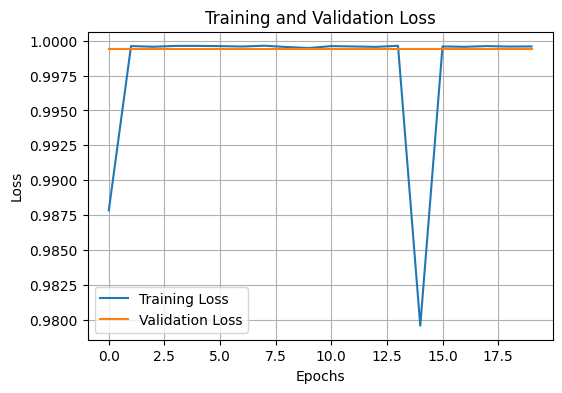

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
tumor_indices = []

# Find slices that actually contain tumor
for i in range(len(Y)):
    if np.sum(Y[i]) > 0:
        tumor_indices.append(i)

print("Number of tumor slices found:", len(tumor_indices))


Number of tumor slices found: 378


In [14]:
selected = tumor_indices[:5]

preds_tumor = model.predict(X[selected])


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [15]:
import numpy as np

def dice_score(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.float32)
    intersection = np.sum(y_true * y_pred)
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0:
        return np.nan
    return (2. * intersection) / denominator


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


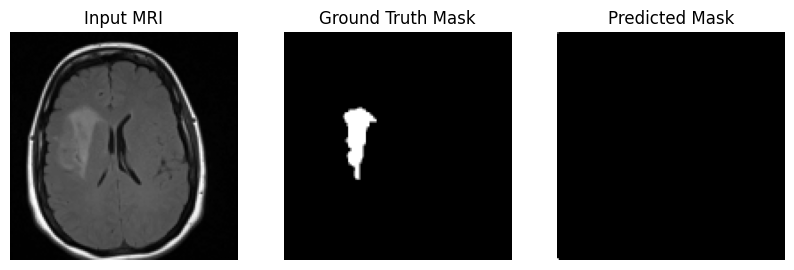

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


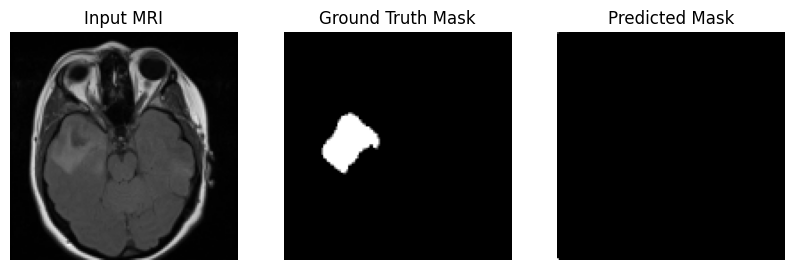

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


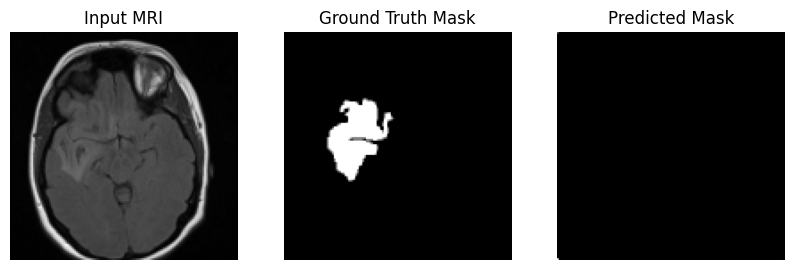

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


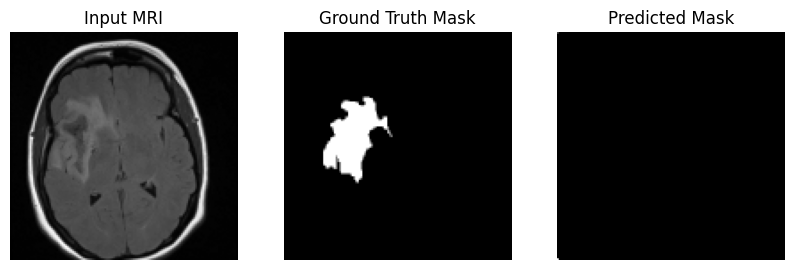

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


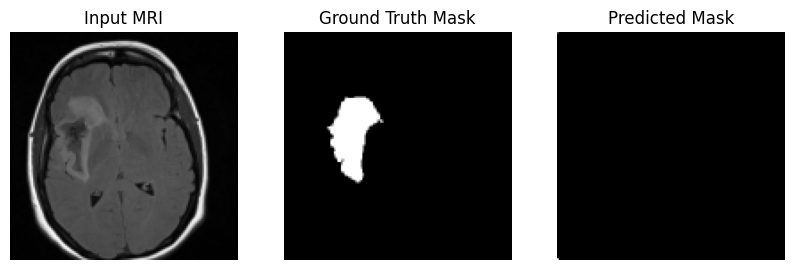

In [16]:
for i in selected:
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Input MRI")
    plt.imshow(X[i].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Ground Truth Mask")
    plt.imshow(Y[i].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Predicted Mask")
    plt.imshow(model.predict(X[i:i+1])[0].squeeze(), cmap='gray')
    plt.axis('off')

    plt.show()


In [17]:
selected = []

for i in range(len(Y)):
    if np.sum(Y[i]) > 0:
        selected.append(i)

print("Tumor slices:", len(selected))


Tumor slices: 378


In [18]:
preds_tumor = model.predict(X[selected[:5]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [19]:
dice_scores = []

for i in range(len(selected[:5])):
    dice = dice_score(Y[selected[i]], preds_tumor[i])
    if not np.isnan(dice):
        dice_scores.append(dice)

print("Dice Scores:", dice_scores)
print("Average Dice Score:", np.mean(dice_scores))


Dice Scores: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Average Dice Score: 0.0


In [20]:
import numpy as np

def iou_score(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.float32)
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    if union == 0:
        return np.nan
    return intersection / union

ious = []

# preds_tumor contains predictions for X[selected[:5]]
# So, we should iterate through preds_tumor and use Y[selected[i]]
for i in range(len(preds_tumor)):
    iou = iou_score(Y[selected[i]], preds_tumor[i])
    if not np.isnan(iou):
        ious.append(iou)

print("Average IoU Score:", np.mean(ious))

Average IoU Score: 0.0


In [21]:
results = {
    "Average Dice Score": float(np.mean(dice_scores)),
    "Average IoU Score": float(np.mean(ious))
}

results


{'Average Dice Score': 0.0, 'Average IoU Score': 0.0}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


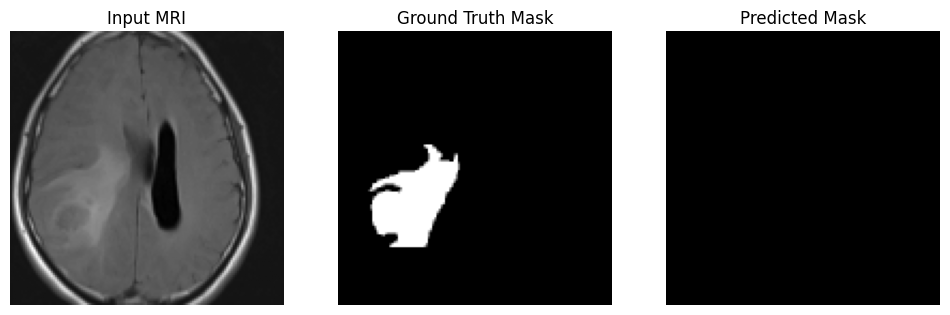

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Select any image index
idx = 150   # change this number to test different images

# Load MRI and mask
img = cv2.imread(image_paths[idx], cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)

# Resize
img = cv2.resize(img, (128,128))
mask = cv2.resize(mask, (128,128))

# Normalize
img = img / 255.0
mask = mask / 255.0

# Expand dimensions
img_input = img.reshape(1,128,128,1)

# Predict
pred = model.predict(img_input)
pred = (pred > 0.5).astype(np.uint8)

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input MRI")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred[0,:,:,0], cmap='gray')
plt.axis('off')

plt.show()
